In [22]:
#lets start multiclass classification

#import all dependencies
import torch
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt



tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


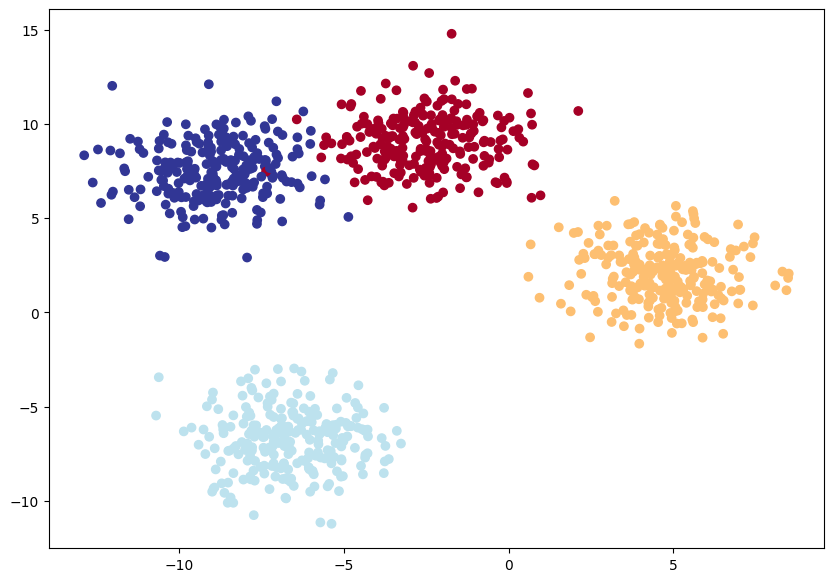

In [23]:
#set the hyperparameters for data creation


num_class = 4
num_features = 2
RANDOM_SEED = 42

#create multi-class data

x_blob,y_blob = make_blobs(n_samples=1000,
                           n_features=num_features, #x features( like x and y coordinate)
                           centers=num_class, #number of class or y labels
                           cluster_std=1.5, #give clusters a little shake up
                           random_state= RANDOM_SEED)

#Turn data into tensors
x_blob = torch.from_numpy(x_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.long) # Changed to torch.long for CrossEntropyLoss

print(x_blob[:5],y_blob[:5])

#split the data into training and test data

x_blob_train, x_blob_test, y_blob_train, y_blob_test = train_test_split(x_blob,y_blob,
                                                    test_size=0.2,
                                                    random_state=RANDOM_SEED)

#plot the data

plt.figure(figsize=(10,7))
plt.scatter(x_blob[:,0],x_blob[:,1],c=y_blob, cmap=plt.cm.RdYlBu);

In [24]:
#create an device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [25]:
#create a multi-classificaion that inherits from nn.Module

class blobs_model(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.Linear_layer_stack= nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_features))


  def forward(self,x):
    return self.Linear_layer_stack(x)

#create an instance of the blobmodel and send it to the device

blobs_model1 = blobs_model(input_features=num_features,
                           output_features=num_class,
                           hidden_units=8).to(device)


In [26]:
#create loss function and optimizer

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(blobs_model1.parameters(),
                            lr=0.1)

In [27]:
#forward a single forward pass on the model(we need to put our model into the device)

blobs_model1(x_blob_train.to(device))[:5]

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [28]:
#how many elements in a single prediction sample?

blobs_model1(x_blob_train.to(device))[1].shape

torch.Size([4])

In [29]:
#make prediction logits with model
y_logits= blobs_model1(x_blob_train.to(device))

#perform softmax activation to logits across dimension1 to get prediction probabilities
y_blob_pred = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_blob_pred[:5])

tensor([[-1.2711, -0.6494, -1.4740, -0.7044],
        [ 0.2210, -1.5439,  0.0420,  1.1531],
        [ 2.8698,  0.9143,  3.3169,  1.4027],
        [ 1.9576,  0.3125,  2.2244,  1.1324],
        [ 0.5458, -1.2381,  0.4441,  1.1804]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.1838, 0.3422, 0.1500, 0.3239],
        [0.2199, 0.0377, 0.1839, 0.5586],
        [0.3406, 0.0482, 0.5326, 0.0785],
        [0.3405, 0.0657, 0.4446, 0.1492],
        [0.2527, 0.0424, 0.2283, 0.4766]], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [30]:
#sum first sampel output out of the softmax activation function

torch.sum(y_blob_pred[1])

tensor(1., device='cuda:0', grad_fn=<SumBackward0>)

In [31]:
#which class is the model think is most likely at the index 0  sampel
print(y_blob_pred[0])
print(torch.argmax(y_blob_pred[1]))

tensor([0.1838, 0.3422, 0.1500, 0.3239], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(3, device='cuda:0')


In [33]:
#time to train the classification model

torch.manual_seed(42)

# Define accuracy function (re-added, as it was removed in a previous edit)
def accuracy_fn(y_true, y_pred_probs):
    y_pred_labels = torch.argmax(y_pred_probs, dim=1) # Get predicted labels from probabilities
    correct = torch.eq(y_true, y_pred_labels).sum().item()
    acc = (correct / len(y_pred_labels)) * 100
    return acc

#put the data into right device
x_blob_train, x_blob_test= x_blob_train.to(device), x_blob_test.to(device)
y_blob_train, y_blob_test = y_blob_train.to(device), y_blob_test.to(device) # Corrected: transfer y_blob_train and y_blob_test

#create epochs to train
epochs= 1000
for epoch in range(epochs):

  blobs_model1.train()

  #forward function
  y_logits = blobs_model1(x_blob_train) # x_blob_train is already on device
  y_blob_pred_probs = torch.softmax(y_logits, dim=1) # Renamed for clarity: probabilities

  #calculate loss and accuracy
  loss = loss_fn(y_logits, y_blob_train)
  accuracy = accuracy_fn(y_true=y_blob_train, y_pred_probs=y_blob_pred_probs) # Corrected keyword argument

  #optimize zero grad
  optimizer.zero_grad() # Corrected typo: optimzer -> optimizer

  #loss backwards
  loss.backward()

  #optimize the model
  optimizer.step()

  #evaluate the model
  blobs_model1.eval()

  with torch.inference_mode(): # Corrected context manager: torch.inference_model -> torch.inference_mode
    test_logits = blobs_model1(x_blob_test) # Corrected typo: x_blobs_test -> x_blob_test
    test_preds_probs = torch.softmax(test_logits, dim=1) # Renamed for clarity: probabilities

    #calculate the test loss and accuracy
    test_loss = loss_fn(test_logits, y_blob_test)
    test_accuracy = accuracy_fn(y_true=y_blob_test, y_pred_probs=test_preds_probs) # Corrected keyword argument
  if epoch % 100==0:

    #print the loss and accuracy of both training and testing
    print(f"epoch:{epoch}| loss:{loss:.5f}| accuracy:{accuracy:.2f}| test_loss:{test_loss:.5f} test_accuracy:{test_accuracy:.2f}")

epoch:0| loss:1.04324| accuracy:65.50| test_loss:0.57861 test_accuracy:95.50
epoch:100| loss:0.03185| accuracy:99.12| test_loss:0.02293 test_accuracy:99.50
epoch:200| loss:0.02707| accuracy:99.12| test_loss:0.01704 test_accuracy:99.50
epoch:300| loss:0.02564| accuracy:99.25| test_loss:0.01499 test_accuracy:99.50
epoch:400| loss:0.02492| accuracy:99.25| test_loss:0.01389 test_accuracy:99.50
epoch:500| loss:0.02444| accuracy:99.25| test_loss:0.01318 test_accuracy:99.50
epoch:600| loss:0.02407| accuracy:99.25| test_loss:0.01265 test_accuracy:99.50
epoch:700| loss:0.02377| accuracy:99.25| test_loss:0.01224 test_accuracy:99.50
epoch:800| loss:0.02349| accuracy:99.25| test_loss:0.01190 test_accuracy:99.50
epoch:900| loss:0.02325| accuracy:99.25| test_loss:0.01160 test_accuracy:99.50


In [35]:
# Make predictions
blobs_model1.eval()
with torch.inference_mode():
    y_logits = blobs_model1(x_blob_test.to(device))

# View the first 10 predictions
y_logits[:10]

tensor([[  6.1117,  18.9106, -22.9632, -14.6995],
        [  9.5662, -23.8503,   5.8412,  17.7025],
        [ -8.4025, -21.8530,  30.5466,  17.0857],
        [  2.1340,  14.6655, -13.7829, -11.2652],
        [ 13.2141,   3.9343, -21.4953,  -3.6479],
        [ 10.8391, -29.6208,   8.5481,  22.0345],
        [ -9.3843, -15.7081,  27.1174,  12.4538],
        [ 11.9275,  -3.3287, -13.8623,   1.9499],
        [ -7.8685, -31.8187,  37.6564,  24.6508],
        [ 12.1832,  -0.6223, -16.3792,  -0.1247]], device='cuda:0')

In [36]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred_probs=y_pred_probs)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Test accuracy: 99.5%


In [37]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


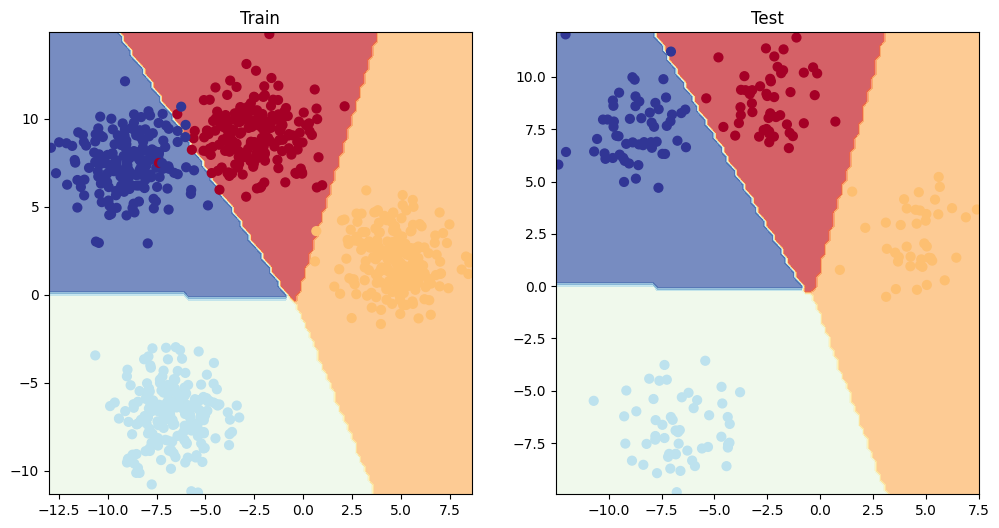

In [38]:
#visualization of the model prediction



plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(blobs_model1, x_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(blobs_model1, x_blob_test, y_blob_test)


In [42]:
#check the accuracy with torchmetrics library

try:
  from torchmetrics import Accuracy
except:
  !pip install torchmetrics==0.09
  from torchmetrics import Accuracy

#setup metrics for the above model
torchmetrics_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

#calculate accuracy
torchmetrics_accuracy( y_preds, y_blob_test)

tensor(0.9950, device='cuda:0')